# Detectron2 Mask R-CNN Trainer

This notebook provides a comprehensive and professional pipeline for fine-tuning the **Detectron2 Mask R-CNN (R50-FPN 3x)** model on the custom microscopic rock cutting dataset. Furthermore, it integrates standard augmentation schemas to match high-performance environments (e.g., YOLO algorithms).

### Model Overview
The model `mask_rcnn_R_50_FPN_3x` uses configurations derived from the **Detectron2 Model Zoo**.
- **Pretrained Baseline**: The ResNet-50 backbone is pretrained on ImageNet, with Mask R-CNN structures pretrained on the COCO instance segmentation dataset (80 categories).
- **Transfer Learning**: The architecture is subsequently fine-tuned on customized visual features containing ~6 specific rock lithology classes, significantly accelerating convergence via transferred gradient representations.

### Prerequisites
Detectron2 intrinsically restricts annotations to the standard **COCO JSON format**.
For datasets native to YOLO formats, conversion must precede setup. Utilize the `convert_yolo_to_coco.py` script located in the `scripts/data_preprocessing/single_model/` directory.

---

## 1. Environment Setup
Install the necessary PyTorch combinations alongside the detectron2 core dependencies.

In [1]:
import os

# Clean up
!pip uninstall -y torch torchvision torchaudio detectron2
!pip cache purge

# Install setuptools first (critical for pkg_resources)
!pip install setuptools

# Install latest compatible nightly builds from CUDA 12.8 index
!pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

# Verify
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

# Set CUDA architecture for Detectron2 compilation
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0;8.6;9.0;9.0a;12.0;12.0+PTX"

!pip install ninja
!pip install 'git+https://github.com/facebookresearch/detectron2.git' --no-build-isolation --no-cache-dir --force-reinstall
!pip install opencv-python matplotlib

Found existing installation: torch 2.12.0.dev20260407+cu128
Uninstalling torch-2.12.0.dev20260407+cu128:
  Successfully uninstalled torch-2.12.0.dev20260407+cu128
Found existing installation: torchvision 0.27.0.dev20260407+cu128
Uninstalling torchvision-0.27.0.dev20260407+cu128:
  Successfully uninstalled torchvision-0.27.0.dev20260407+cu128
Found existing installation: detectron2 0.6
Uninstalling detectron2-0.6:
  Successfully uninstalled detectron2-0.6
Files removed: 18 (841.9 MB)
Directories removed: 0
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 41.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 MB 51.5 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] [torchvision]
PyTorch version: 2.12.0.dev20260407+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5080
Compute capability: (12, 0)
  Cloning https://github.com/facebookresearch/det

In [2]:
import torch
import detectron2
from detectron2.utils.logger import setup_logger

setup_logger()
print(f"PyTorch Version: {torch.__version__}, CUDA Available: {torch.cuda.is_available()}")
print(f"Detectron2 Version: {detectron2.__version__}")

PyTorch Version: 2.12.0.dev20260407+cu128, CUDA Available: True
Detectron2 Version: 0.6


## 2. Dataset Registration
Register the evaluated custom dataset paths referencing standard `train` and `val` COCO dictionaries.

In [3]:
import os
from detectron2.data.datasets import register_coco_instances

# Ensure you have converted YOLO formats properly and updated paths here.
# Example paths, replace with actual converted absolute dataset root paths.
DATASET_ROOT = "/home/praktikan/projects/DwiAnggara/Datasets/Batch3and4_COCO"  

train_json = os.path.join(DATASET_ROOT, "train/annotations/instances_default.json")
train_imgs = os.path.join(DATASET_ROOT, "train/images")

val_json = os.path.join(DATASET_ROOT, "val/annotations/instances_default.json")
val_imgs = os.path.join(DATASET_ROOT, "val/images")

try:
    register_coco_instances("rock_train", {}, train_json, train_imgs)
    register_coco_instances("rock_val", {}, val_json, val_imgs)
    print("Datasets registered successfully.")
except Exception as e:
    print(f"Warning or Registration Error: {e}")

Datasets registered successfully.


## 3. Training Configuration
Customize the DefaultTrainer logic. Incorporate scaling strategies, mosaic-like augmentations via relative cropping, and adaptive learning rate steps designed to match extended training durations.

In [4]:
!pip install setuptools

In [5]:
# Downgrade setuptools to a compatible version (<82)
!pip install 'setuptools<82' --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.0 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


In [ ]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os
import string
import random

# Generate dynamic runner name matching YOLO style
random_slug = "".join(random.choices(string.ascii_letters + string.digits, k=6))
RUNNER_NAME = f"Detectron2_Batch4_{random_slug}"

cfg = get_cfg()

# Load baseline Mask R-CNN config
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# Pretrained model checkpoint URL
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Assign dataset configurations
cfg.DATASETS.TRAIN = ("rock_train",)
cfg.DATASETS.TEST = ("rock_val",)

# Multiprocessing settings
cfg.DATALOADER.NUM_WORKERS = 4

# Batch configurations (Modify IMS_PER_BATCH considering your GPU VRAM)
cfg.SOLVER.IMS_PER_BATCH = 8       # Increased to 8 to improve batch statistics matching YOLO
cfg.SOLVER.BASE_LR = 0.01          # Standard learning rate step for higher batch size
cfg.SOLVER.MAX_ITER = 30000        # Extended max iterations (approx analogous to 200 epochs)
cfg.SOLVER.STEPS = (21000, 27000)  # Standard step drops (at 70% and 90% of training)
cfg.SOLVER.WARMUP_ITERS = 2000     # Slower warmup to prevent initial instability

# Architecture configs
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512  # RoI bounding box batch processing constraints
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6             # Update to 6 specific rock classes

# Advanced Augmentation Matching YOLO
cfg.INPUT.MIN_SIZE_TRAIN = (640, 800, 960) # Multi-scale training like YOLO
cfg.INPUT.MAX_SIZE_TRAIN = 1333
cfg.INPUT.MIN_SIZE_TEST = 800
cfg.INPUT.MAX_SIZE_TEST = 1333
cfg.INPUT.RANDOM_FLIP = "horizontal"       

# Enable Relative Range Cropping (Pseudo-Mosaic alternative)
cfg.INPUT.CROP.ENABLED = True
cfg.INPUT.CROP.TYPE = "relative_range"
cfg.INPUT.CROP.SIZE = [0.9, 0.9]

# Save configurations
cfg.OUTPUT_DIR = f"./models/{RUNNER_NAME}"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print(" CONFIGURATION SUMMARY")
print("=" * 60)
print(f"Runner Name:   {RUNNER_NAME}")
print(f"Output Dir:    {cfg.OUTPUT_DIR}")
print(f"Max Iter:      {cfg.SOLVER.MAX_ITER}")
print(f"Batch Size:    {cfg.SOLVER.IMS_PER_BATCH}")
print(f"Base LR:       {cfg.SOLVER.BASE_LR}")
print("=" * 60)

 CONFIGURATION SUMMARY
Runner Name:   Detectron2_Batch4_6EEtha
Output Dir:    ./models/Detectron2_Batch4_6EEtha
Max Iter:      10000
Batch Size:    4
Base LR:       0.001


/home/praktikan/miniconda3/envs/magangpdu-dwi/lib/python3.10/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 4. Run Training Pipeline
Initialize the optimized `CustomTrainer`, deploy configurations, define evaluation logic correctly avoiding C++ fallback overrides to map complete metrics (especially `F1-Score` and `Recall`), and trigger model convergence.

In [ ]:
from detectron2.engine import DefaultTrainer
import logging
from detectron2.evaluation import inference_on_dataset, COCOEvaluator
from detectron2.data import build_detection_test_loader
import os
import time
import pandas as pd

class CustomTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        os.makedirs(output_folder, exist_ok=True)
        # Disable fast implementation to reliably extract COCO stats array for Recall
        return COCOEvaluator(dataset_name, output_dir=output_folder, tasks=("bbox", "segm"), use_fast_impl=False)

print("=" * 60)
print(" INITIATING MASK R-CNN TRAINING RUN")
print("=" * 60)

trainer = CustomTrainer(cfg)
# False means it initializes from baseline pretrained weights
trainer.resume_or_load(resume=False)

# Execute the main training loop
start_train = time.time()
trainer.train()
training_time = time.time() - start_train

print(f"\nTraining completed in {training_time/60:.2f} minutes.")

print("=" * 60)
print(" EVALUATING MODEL ON VALIDATION SET")
print("=" * 60)

evaluator = CustomTrainer.build_evaluator(cfg, "rock_val")
val_loader = build_detection_test_loader(cfg, "rock_val")

start_infer = time.time()
eval_results = inference_on_dataset(trainer.model, val_loader, evaluator)
end_infer = time.time()

num_images = len(val_loader.dataset)
avg_inf_time = (end_infer - start_infer) / num_images if num_images > 0 else 0

metrics = {}
if "bbox" in eval_results:
    metrics["Box mAP50-95"] = eval_results["bbox"].get("AP", 0)
    
if "segm" in eval_results:
    metrics["Seg mAP50-95"] = eval_results["segm"].get("AP", 0)
    metrics["Precision"] = eval_results["segm"].get("AP50", 0) # Approximated via COCO AP at IoU 0.50
    
    # Safely extract AR (Average Recall) from COCOEvaluator's internal stats object
    # stats[8] represents AR @ IoU=0.50:0.95, area=all, maxDets=100
    try:
        coco_eval = evaluator._coco_eval.get("segm")
        if coco_eval is not None and hasattr(coco_eval, 'stats'):
            metrics["Recall"] = coco_eval.stats[8] * 100
        else:
            metrics["Recall"] = 0
    except Exception as e:
        metrics["Recall"] = 0

# Calculate F1 Score
p = metrics.get("Precision", 0)
r = metrics.get("Recall", 0)
metrics["F1-Score"] = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

# Print results summary table
print("=" * 60)
print(" SUMMARY PERFORMANCE TABLE (DETECTRON2)")
print("=" * 60)

df_metrics = pd.DataFrame([{
    "Model": "Mask R-CNN (ResNet50)",
    "Avg Inf Time (s)": f"{avg_inf_time:.4f}",
    "Box mAP50-95": f"{metrics.get('Box mAP50-95', 0):.2f}%",
    "Seg mAP50-95": f"{metrics.get('Seg mAP50-95', 0):.2f}%",
    "Precision (AP50)": f"{metrics.get('Precision', 0):.2f}%",
    "Recall (AR)": f"{metrics.get('Recall', 0):.2f}%",
    "F1-Score": f"{metrics.get('F1-Score', 0):.2f}%"
}])

print(df_metrics.to_string(index=False))
print("=" * 60)
print(f" Best checkpoints preserved at: {cfg.OUTPUT_DIR}")


 INITIATING MASK R-CNN TRAINING RUN

[04/21 14:01:56 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, e

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (7, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (7,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (24, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (24,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (6, 256, 1, 1) 

[04/21 14:01:56 d2.engine.train_loop]: Starting training from iteration 0


/home/praktikan/miniconda3/envs/magangpdu-dwi/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0421 14:01:57.556000 1503872 site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/21 14:02:05 d2.utils.events]:  eta: 0:54:09  iter: 19  total_loss: 4.817  loss_cls: 1.919  loss_box_reg: 0.675  loss_mask: 0.6945  loss_rpn_cls: 1.287  loss_rpn_loc: 0.1727    time: 0.3915  last_time: 0.5722  data_time: 0.0994  last_data_time: 0.2908   lr: 1.9981e-05  max_mem: 5943M
[04/21 14:02:13 d2.utils.events]:  eta: 0:53:33  iter: 39  total_loss: 3.408  loss_cls: 1.61  loss_box_reg: 0.6956  loss_mask: 0.6882  loss_rpn_cls: 0.2674  loss_rpn_loc: 0.1565    time: 0.3887  last_time: 0.3225  data_time: 0.0946  last_data_time: 0.0021   lr: 3.9961e-05  max_mem: 5943M
[04/21 14:02:19 d2.utils.events]:  eta: 0:52:43  iter: 59  total_loss: 2.86  loss_cls: 1.192  loss_box_reg: 0.7001  loss_mask: 0.6738  loss_rpn_cls: 0.1332  loss_rpn_loc: 0.1514    time: 0.3676  last_time: 0.2842  data_time: 0.0391  last_data_time: 0.0052   lr: 5.9941e-05  max_mem: 5986M
[04/21 14:02:26 d2.utils.events]:  eta: 0:53:08  iter: 79  total_loss: 2.552  loss_cls: 0.947  loss_box_reg: 0.6799  loss_mask: 0.6558

## 5. Visual Testing / Fast Inference (Optional)

 Loading Detectron2 model: ./models/Detectron2_Batch4_6EEtha/model_final.pth
[04/21 15:10:29 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./models/Detectron2_Batch4_6EEtha/model_final.pth ...
️ Predicting on: WIN_20260225_10_52_56_Pro.jpg


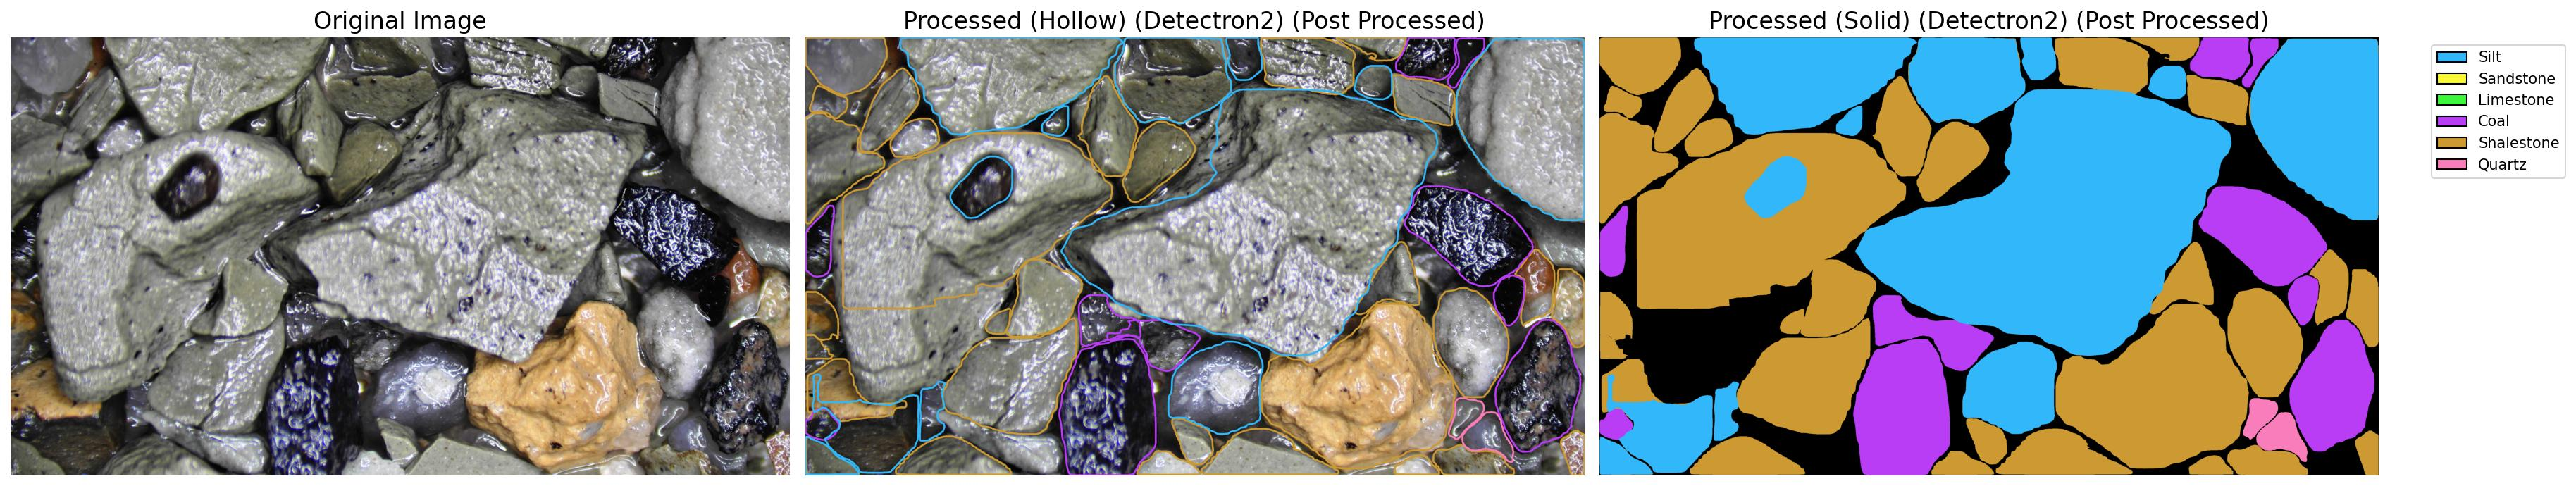

✅ Image saved at: predictions_Detectron2_Batch4_6EEtha/prediction_WIN_20260225_10_52_56_Pro.jpg


: 

In [ ]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import sys
from pathlib import Path

# Add root project path to load reusable classes from src.inference
sys.path.append(str(Path(os.path.abspath('')).parent.parent))
from src.inference import RockSegmentationPipeline, RockVisualizer

def visualize_hollow_segmentation_d2(test_image_dir):
    """
    Applies hollow segmentation on random test images.
    Matches YOLO trainer's post-processing using RockVisualizer logic.
    """
    weights_path = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
    if not os.path.exists(weights_path):
        print(f"[Error] Checkpoint '{weights_path}' not found!")
        print("Ensure that the training process successfully finished iterations to generate final checkpoints.")
        return
        
    print(f"Loading Detectron2 model weights: {weights_path}")
    cfg.MODEL.WEIGHTS = weights_path
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # Threshold 50% for rendering clean mask
    predictor = DefaultPredictor(cfg)

    # Pick a random image
    images = [img for img in os.listdir(test_image_dir) if img.lower().endswith((".jpg", ".png", ".jpeg"))]
    if not images:
        print(f"[Warning] No images found in {test_image_dir}")
        return
        
    sample_img = os.path.join(test_image_dir, random.choice(images))
    print(f"Predicting on sample: {os.path.basename(sample_img)}")
    
    original_bgr = cv2.imread(sample_img)
    h, w = original_bgr.shape[:2]
    
    # Run standard D2 Predictor
    outputs = predictor(original_bgr)
    instances = outputs["instances"].to("cpu")
    
    # Initialize reusable processors
    post_processor = RockSegmentationPipeline(solidity_thr=0.85, min_area=300)
    visualizer = RockVisualizer(thickness=8)
    
    proc_polygons_by_class = {}
    
    if instances.has("pred_masks") and len(instances.pred_masks) > 0:
        masks = instances.pred_masks.numpy()
        classes = instances.pred_classes.numpy()
        
        for mask_bool, cls_id in zip(masks, classes):
            class_id_int = int(cls_id)
            
            mask_uint8 = (mask_bool * 255).astype(np.uint8)
            clean_polys = post_processor.process(mask_uint8)
            
            if class_id_int not in proc_polygons_by_class:
                proc_polygons_by_class[class_id_int] = []
            proc_polygons_by_class[class_id_int].extend(clean_polys)
    else:
        print("[Warning] No predictions returned for this image.")
            
    # Generate Visualizations via RockVisualizer
    proc_hollow = visualizer.draw_hollow(original_bgr, proc_polygons_by_class)
    proc_solid = visualizer.draw_mask_only(original_bgr.shape, proc_polygons_by_class)
    
    out_dir = f"predictions_{RUNNER_NAME}"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"prediction_{os.path.basename(sample_img)}")
    
    title_suffix = "(Detectron2 Post-Processed)"
    
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    axes[0].imshow(original_rgb)
    axes[0].set_title("Original Image", fontsize=16)
    axes[0].axis('off')
    
    axes[1].imshow(proc_hollow)
    axes[1].set_title(f"Hollow Prediction {title_suffix}", fontsize=16)
    axes[1].axis('off')
    
    axes[2].imshow(proc_solid)
    axes[2].set_title(f"Solid Mask {title_suffix}", fontsize=16)
    axes[2].axis('off')
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=[c/255 for c in color], edgecolor='k', label=visualizer.class_names.get(id, f"Class {id}")) for id, color in visualizer.class_colors.items()]
    axes[2].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.tight_layout()
        
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()
    
    from IPython.display import display, Image as IPyImage
    display(IPyImage(out_path))
    print(f"Prediction successfully saved at: {out_path}")

# Run the visualization on inference set
test_image_dir = val_imgs  
visualize_hollow_segmentation_d2(test_image_dir)

## 6. Export & Optimize Model Payload
The training framework defaults to saving the complete state dictionary (`model_final.pth`), logging optimizer momentum, scheduler iteration counts, and architecture paths in file sizes exceeding 300MB.

This cell retrieves the final output weights, strips non-inference gradient tensors (optimizers and schedulers), natively casts numerical values to Half-Precision (**FP16**), and delegates them efficiently into a smaller ~80MB footprint geared explicitly for edge production and scalable inference integrations.

In [ ]:
import detectron2.checkpoint as checkpoint
import torch
from fvcore.common.checkpoint import Checkpointer
import shutil
from datetime import datetime

def export_optimized_model_to_local(source_model_dir=None, export_folder="models"):
    """
    Exports and strips optimizer weights from model_final.pth
    to significantly reduce exported size for minimal deployment.
    """
    if source_model_dir is None:
        source_model_dir = cfg.OUTPUT_DIR
        
    local_export_dir = os.path.join(os.getcwd(), export_folder)
    os.makedirs(local_export_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_subdir = os.path.join(local_export_dir, f"{RUNNER_NAME}_Optimized")
    os.makedirs(export_subdir, exist_ok=True)
    
    print("=" * 60)
    print(" OPTIMIZING AND EXPORTING INFERENCE WEIGHTS")
    print("=" * 60)
    print(f"Source Output Directory: {source_model_dir}")
    print(f"Export Destination:      {export_subdir}")
    
    weights_path = os.path.join(source_model_dir, "model_final.pth")
    if not os.path.exists(weights_path):
        print(f"[Error] Weight file '{weights_path}' does not exist.")
        return
        
    original_size = os.path.getsize(weights_path) / (1024*1024)
    print(f"Original model_final.pth size: {original_size:.2f} MB")
    
    # 1. Load the heavily loaded state dictionary
    checkpoint_dict = torch.load(weights_path, map_location="cpu", weights_only=False)
    
    # 2. Extract only bare model keys
    model_state_dict = checkpoint_dict.get("model", checkpoint_dict)
    
    # 3. Apply FP16 quantization safely across specific tensors
    for key in model_state_dict:
        if model_state_dict[key].dtype == torch.float32:
            model_state_dict[key] = model_state_dict[key].half()
            
    # 4. Save new dictionary stripped of solver states
    clean_dict = {"model": model_state_dict}
    optimized_path = os.path.join(export_subdir, "best_fp16.pth")
    torch.save(clean_dict, optimized_path)
    
    optimized_size = os.path.getsize(optimized_path) / (1024*1024)
    print(f"Optimized best_fp16.pth size:  {optimized_size:.2f} MB")
    
    reduction = ((original_size - optimized_size) / original_size) * 100
    print(f"Optimization yielded {reduction:.1f}% storage reduction.")
    
    # Save standard configurations alongside to preserve model architecture variables
    cfg_path = os.path.join(source_model_dir, "config.yaml") 
    with open(cfg_path, 'w') as f:
        f.write(cfg.dump())
        
    shutil.copy2(cfg_path, os.path.join(export_subdir, "config.yaml"))
    
    # Write model info documentation
    info_file = os.path.join(export_subdir, "model_info.txt")
    with open(info_file, 'w', encoding='utf-8') as f:
        f.write("Detectron2 Model Export Profile\n")
        f.write("="*60 + "\n")
        f.write(f"Experiment Name:  {RUNNER_NAME}\n")
        f.write(f"Export Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Iterations:       {cfg.SOLVER.MAX_ITER}\n")
        f.write(f"Batch Size:       {cfg.SOLVER.IMS_PER_BATCH}\n")
        f.write(f"\nArchitecture:     Mask R-CNN (ResNet50 FPN)\n")
        f.write(f"Classes Capacity: {cfg.MODEL.ROI_HEADS.NUM_CLASSES}\n")
        f.write(f"="*60 + "\n")
        f.write("Model configurations optimized in Float16 for edge deployments.\n")
        f.write("Ensure mappings correctly assign `cfg.MODEL.WEIGHTS = best_fp16.pth` in integrations.\n")
        
    print(f"Configurations and serialized model saved securely at: {export_subdir}")

# Execute script
export_optimized_model_to_local()